In [1]:
import pandas as pd


In [2]:
df=pd.read_csv('/Users/annas_05/Downloads/Dataset of Diabetes .csv')

In [3]:
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(8), int64(4), object(2)
memory usage: 109.5+ KB


In [12]:
df.select_dtypes(include="object").columns


Index(['Gender', 'CLASS'], dtype='object')

In [16]:
df["Gender"].value_counts()

Gender
M    565
F    434
f      1
Name: count, dtype: int64

In [18]:
df["Gender"] = df["Gender"].str.replace("f", "F")


In [21]:
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns


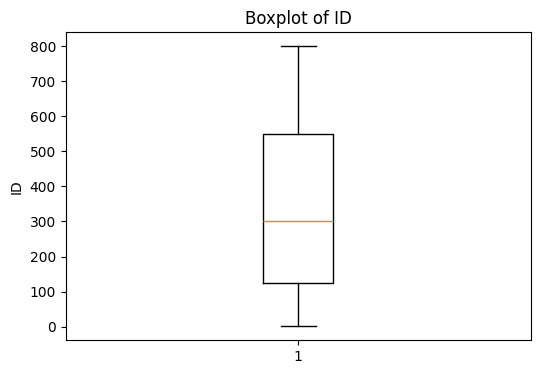

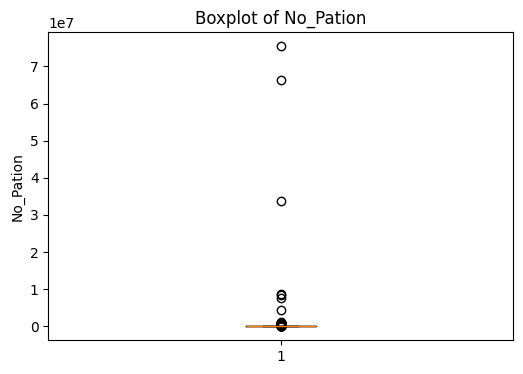

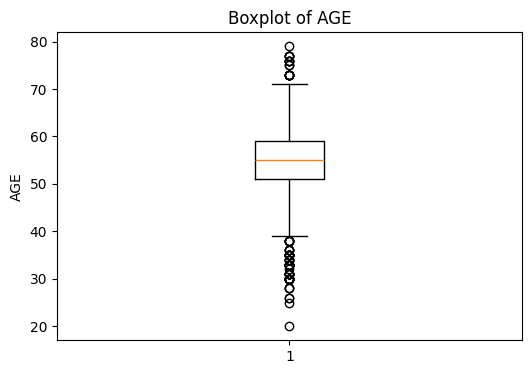

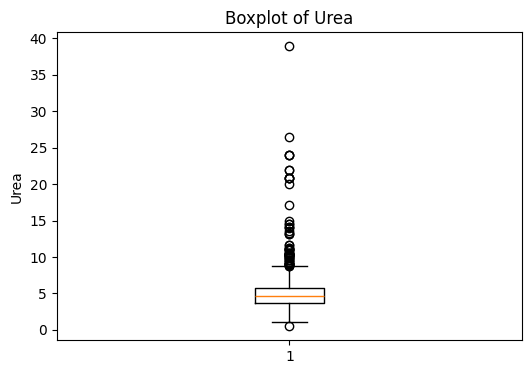

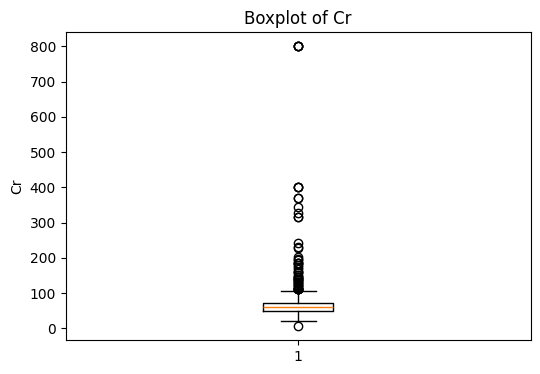

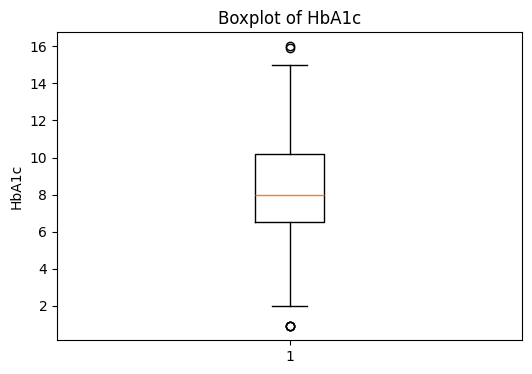

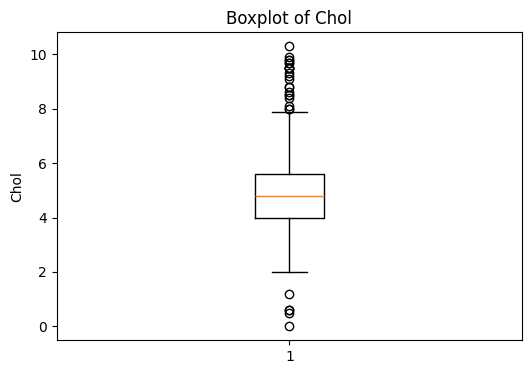

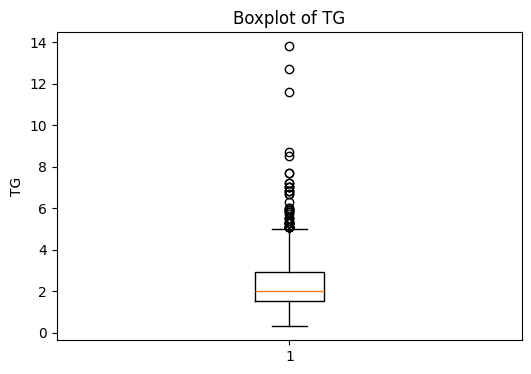

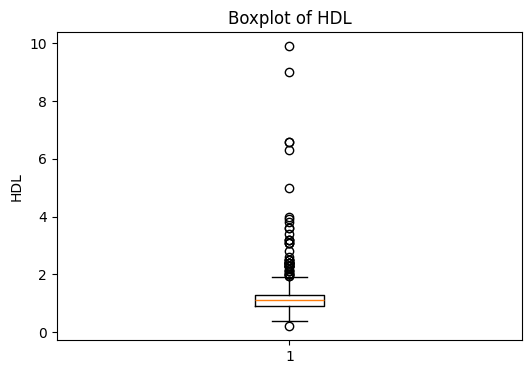

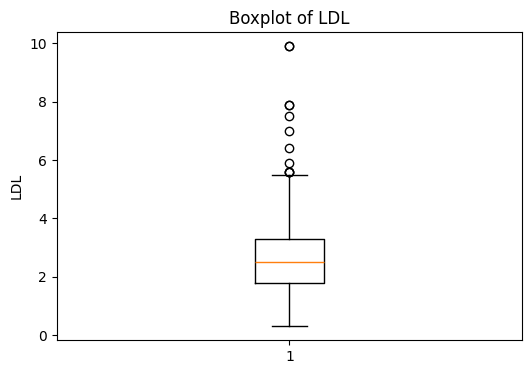

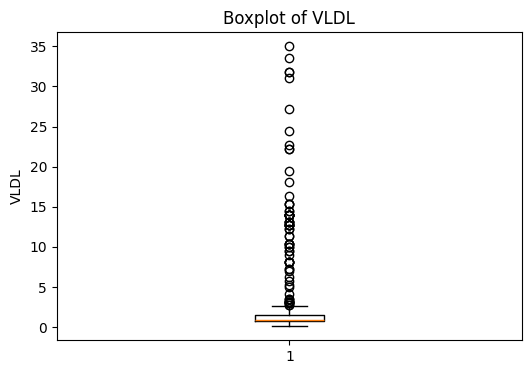

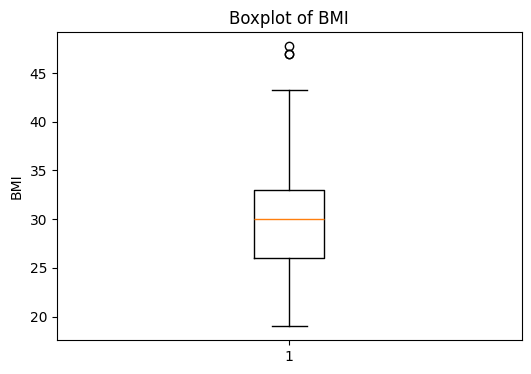

In [22]:
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()


In [23]:
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns

outlier_counts = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_counts[col] = ((df[col] < lower) | (df[col] > upper)).sum()

outlier_counts


{'ID': np.int64(0),
 'No_Pation': np.int64(107),
 'AGE': np.int64(98),
 'Urea': np.int64(65),
 'Cr': np.int64(52),
 'HbA1c': np.int64(6),
 'Chol': np.int64(27),
 'TG': np.int64(55),
 'HDL': np.int64(50),
 'LDL': np.int64(11),
 'VLDL': np.int64(74),
 'BMI': np.int64(3)}

In [24]:
df_clipped = df.copy()

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_clipped[col] = df[col].clip(lower, upper)


In [25]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns
cat_cols


Index(['Gender', 'CLASS'], dtype='object')

In [27]:
df_encoded = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)


In [28]:
import numpy as np
from sklearn.preprocessing import StandardScaler

num_cols = df.select_dtypes(include=np.number).columns


In [29]:
scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wenruliu/adult-income-dataset")

print("Path to dataset files:", path)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/annas_05/.cache/kagglehub/datasets/wenruliu/adult-income-dataset/versions/2


In [6]:
import os
os.listdir(path)

['adult.csv']

In [9]:
import os
os.getcwd()


'/Users/annas_05'

In [10]:
import os
import pandas as pd

df1 = pd.read_csv(os.path.join(path, "adult.csv"))


In [11]:
df1.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [30]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [13]:
import numpy as np

num_cols = df1.select_dtypes(include=np.number).columns


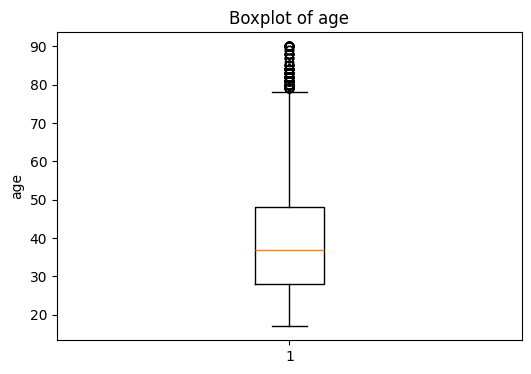

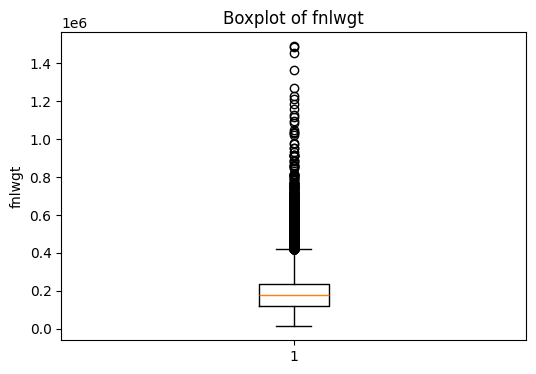

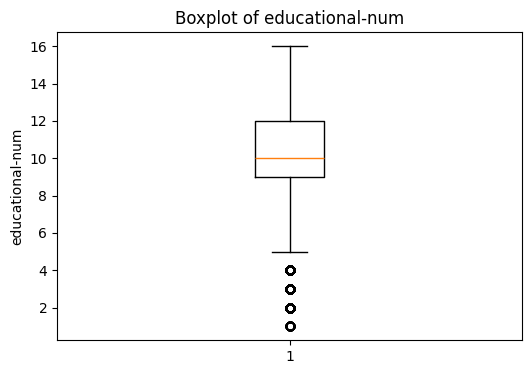

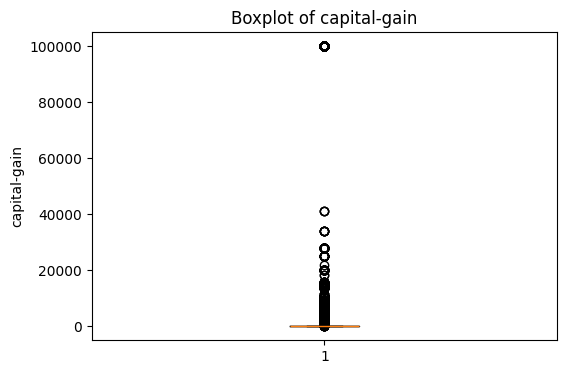

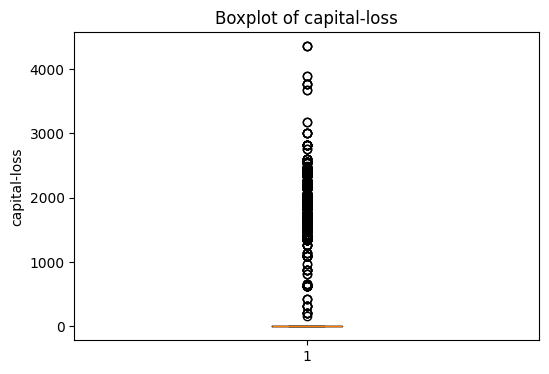

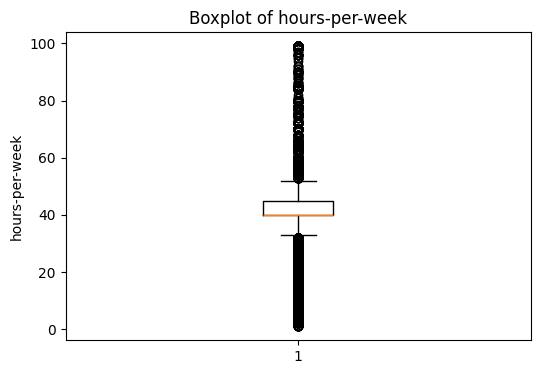

In [15]:
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df1[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()


In [36]:
cat_cols1=df1.select_dtypes(include="object").columns


In [32]:
import numpy as np

df1["occupation"] = df1["occupation"].replace("?", np.nan)


In [33]:
occupation_mode = df1["occupation"].mode()[0]


In [34]:
df1["occupation"] = df1["occupation"].fillna(occupation_mode)


In [37]:
df1_encoded = pd.get_dummies(
    df1,
    columns=cat_cols1,
    drop_first=True
)


In [38]:
import numpy as np

num_cols = df1.select_dtypes(include=np.number).columns

outlier_counts = {}

for col in num_cols:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_counts[col] = ((df1[col] < lower) | (df1[col] > upper)).sum()

outlier_counts


{'age': np.int64(216),
 'fnlwgt': np.int64(1453),
 'educational-num': np.int64(1794),
 'capital-gain': np.int64(4035),
 'capital-loss': np.int64(2282),
 'hours-per-week': np.int64(13496)}

In [39]:
df1_clipped = df1.copy()

for col in num_cols:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df1_clipped[col] = df1[col].clip(lower, upper)


In [40]:
import numpy as np
from sklearn.preprocessing import StandardScaler

num_cols = df1.select_dtypes(include=np.number).columns


In [41]:
scaler = StandardScaler()

df1_scaled = df1.copy()
df1_scaled[num_cols] = scaler.fit_transform(df1[num_cols])
